In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import optuna
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-paper')
sns.set_context("paper", font_scale=1.5)
sns.set_palette("Set2")
plt.rc('font', size=12)          
plt.rc('axes', titlesize=14)     
plt.rc('axes', labelsize=12)     
plt.rc('xtick', labelsize=11)    
plt.rc('ytick', labelsize=11)    
plt.rc('legend', fontsize=11)    
plt.rc('figure', titlesize=16)
PATH = os.getcwd()
sys.path.append(PATH)

In [2]:
exp_A_tags = {
    '-FIXP-LB-LT': 'A2', '-FIXP-LB': 'A3', '-FIXP-LT': 'A4', '-FIXP': 'A1',
    '-LB-LT' : 'A6', '-LB': 'A7', '-LT': 'A8'
}
default_config_A = 'A5'
exp_B_tags = {'-T1': 'T=1','-T5': 'T=5','-T10': 'T=10', '-T20': 'T=20', '-T30': 'T=30','-T40': 'T=40', '-T50': 'T=50'}
exp_C_tags = {'-S5': '$\sigma$=5', '-S10': '$\sigma$=10', '-S20': '$\sigma$=20', '-S30': '$\sigma$=30', '-S40': '$\sigma$=40', '-S50': '$\sigma$=50'}
data = []
databases = [
    "EXP_A.db",
    "EXP_B.db",
    "EXP_C.db",
    "EXP_D1-ml.db",
    "EXP_D2-max.db",
    "EXP_D2-mean.db",
]

def extract_data():
    for db in databases:
        db_path = os.path.join(PATH, "results", db)
        if not os.path.exists(db_path):
            print(f"Not found - {db_path}")
            continue
        storage_url = f"sqlite:///{db_path}"
        print(f"Extracting data from {db}")
        try:
            summaries = optuna.get_all_study_summaries(storage=storage_url)
            for summary in summaries:
                study_name = summary.study_name
                study = optuna.load_study(study_name=study_name, storage=storage_url)
                model = "CSNN" if "CSNN" in study_name else "FFSNN" if "FFSNN" in study_name else "Other"
                exp_group = "Unknown"
                config = "Unknown"
                if "EXP_A" in db or "A-" in study_name:
                    exp_group = "Exp A (Learning)"
                    dataset='BAF-Base'
                    config = default_config_A 
                    for suffix, tag in exp_A_tags.items():
                        if suffix in study_name: config = tag; break
                elif  "EXP_B" in db and ("T5" in study_name or "T10" in study_name or "T20" in study_name or "T30" in study_name or "T40" in study_name or "T50" in study_name):
                    exp_group = "Exp B (Timesteps)"
                    dataset='BAF-Base'
                    for suffix, tag in exp_B_tags.items():
                        if suffix in study_name: config = tag
                elif  "EXP_C" in db and ("S5" in study_name or "S10" in study_name or "S20" in study_name or "S30" in study_name or "S40" in study_name or "S50" in study_name):
                    exp_group = "Exp C (Slopes)"
                    dataset='BAF-Base'
                    for suffix, tag in exp_C_tags.items():
                        if suffix in study_name: config = tag
                elif "EXP_D1" in db:
                    exp_group = "Exp D1 (ML Models)"
                    dataset='BAF-' + study_name.split('-')[1]
                    model= study_name.split('-')[2]
                    config = study_name
                elif "EXP_D2-max" in db:
                    exp_group = "Exp D2 (SNN - Max)"
                    dataset='BAF-' + study_name.split('-')[1]
                    model= study_name.split('-')[2]
                    config = 'Max'
                elif "EXP_D2-mean" in db:
                    exp_group = "Exp D2 (SNN - Mean)"
                    dataset='BAF-' + study_name.split('-')[1]
                    model= study_name.split('-')[2]
                    config = 'Mean'
                for trial in study.trials[:100]:
                    if trial.state == optuna.trial.TrialState.COMPLETE:
                        row = {
                            'Exp_Group': exp_group,
                            'Config': config,
                            'Model': model,
                            'Dataset': dataset,
                            'Recall': trial.value,
                            'PE$_{\\text{Age}}$': trial.user_attrs.get('@fair fpr_ratio_age', np.nan),
                            'ROC-AUC': trial.user_attrs.get('@perf roc_auc', np.nan),
                            'PR-AUC': trial.user_attrs.get('@perf pr_auc', np.nan)
                        }
                        data.append(row)
        except Exception as e:
            print(f"Error reading {db}: {e}")
extract_data()
df_all = pd.DataFrame(data)
print(f"Total trials extracted: {len(df_all)}")
df_all

Extracting data from EXP_A.db
Extracting data from EXP_B.db
Extracting data from EXP_C.db
Extracting data from EXP_D1-ml.db
Extracting data from EXP_D2-max.db
Extracting data from EXP_D2-mean.db
Total trials extracted: 11475


,Exp_Group,Config,Model,Dataset,Recall,PE$_{\text{Age}}$,ROC-AUC,PR-AUC
0,Exp A (Learning),A1,FFSNN,BAF-Base,0.453782,0.368890,0.850423,0.146558
1,Exp A (Learning),A1,FFSNN,BAF-Base,0.459384,0.279481,0.852156,0.142354
2,Exp A (Learning),A1,FFSNN,BAF-Base,0.452381,0.308038,0.844861,0.117526
3,Exp A (Learning),A1,FFSNN,BAF-Base,0.443978,0.313811,0.845311,0.109323
4,Exp A (Learning),A1,FFSNN,BAF-Base,0.480392,0.329113,0.856929,0.161905
...,...,...,...,...,...,...,...,...
11470,Exp D2 (SNN - Mean),Mean,CSNN,BAF-TypeV,0.414634,0.528182,0.834265,0.083723
11471,Exp D2 (SNN - Mean),Mean,CSNN,BAF-TypeV,0.402439,0.434405,0.839913,0.094865
11472,Exp D2 (SNN - Mean),Mean,CSNN,BAF-TypeV,0.314024,0.468889,0.821774,0.084998
11473,Exp D2 (SNN - Mean),Mean,CSNN,BAF-TypeV,0.358740,0.343179,0.819465,0.092693


In [3]:
df_A = df_all[df_all['Exp_Group'] == 'Exp A (Learning)'].copy().sort_values(by=['Model', 'Config'])
max_values = df_A.groupby(['Model', 'Config'])['Recall'].max().reset_index()
max_values

,Model,Config,Recall
0,CSNN,A1,0.509804
1,CSNN,A2,0.509804
2,CSNN,A3,0.509804
3,CSNN,A4,0.521008
4,CSNN,A5,0.511905
5,CSNN,A6,0.509804
6,CSNN,A7,0.513305
7,CSNN,A8,0.507703
8,FFSNN,A1,0.499300
9,FFSNN,A2,0.494398


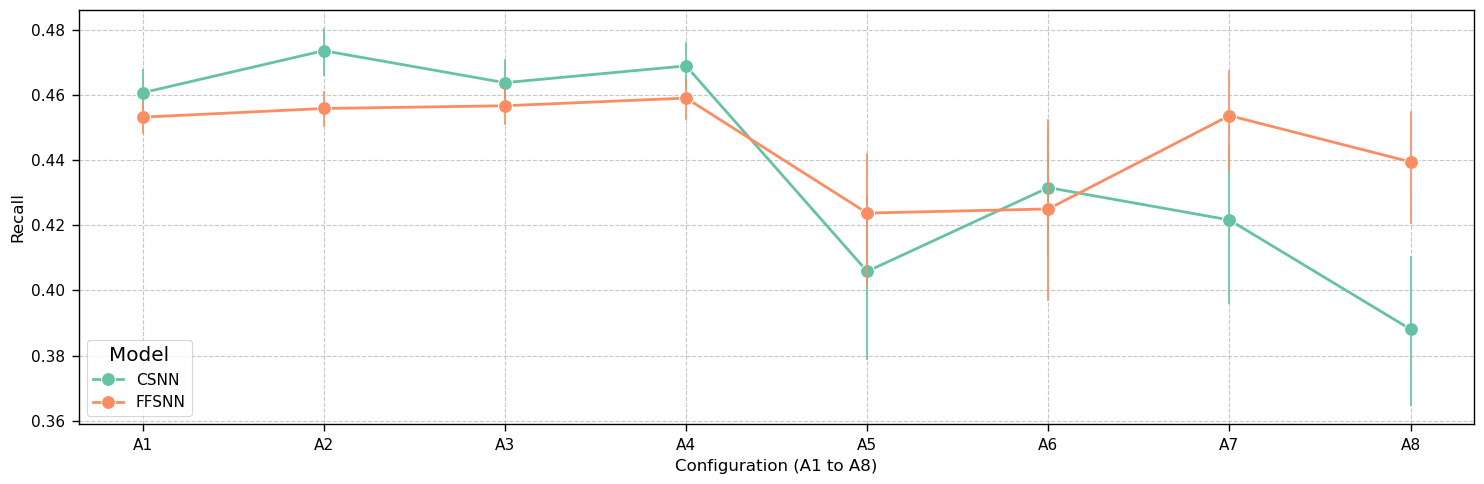

In [4]:
fig, axes = plt.subplots(1, 1, figsize=(15, 5))
sns.lineplot(data=df_A, x='Config', y='Recall', hue='Model', marker='o', markersize=10, linewidth=2, err_style="bars")
plt.xlabel('Configuration (A1 to A8)')
plt.ylabel('Recall')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.legend(title='Model', loc='lower left')
#plt.savefig(os.path.join(PATH, 'plots/exp_a_lineplot.pdf'), dpi=300, bbox_inches='tight', pad_inches=0.1)
plt.show()

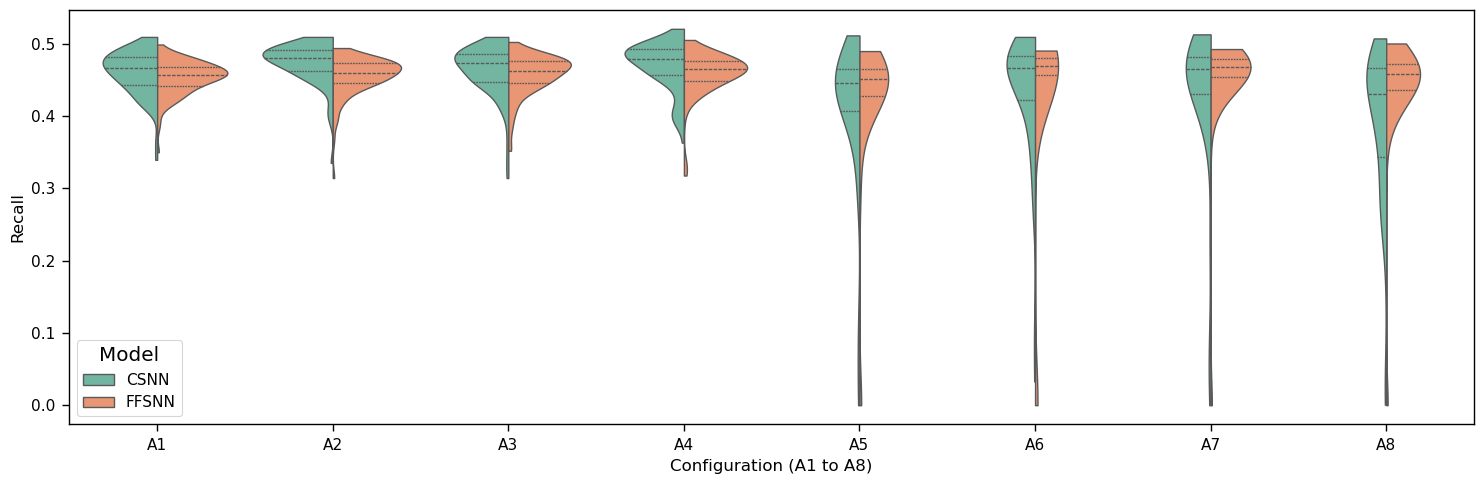

In [5]:
df_A = df_all[df_all['Exp_Group'] == 'Exp A (Learning)'].copy()
df_A = df_A.sort_values(by=['Model', 'Config'])
fig, axes = plt.subplots(1, 1, figsize=(15, 5))
sns.violinplot(data=df_A, x='Config', y='Recall', hue='Model', split=True, inner="quart", ax=axes, cut=0)
axes.set_xlabel('Configuration (A1 to A8)')
axes.set_ylabel('Recall')
axes.legend(title='Model', loc='lower left')
plt.tight_layout()
#plt.savefig(os.path.join(PATH, 'plots/exp_a_violin.pdf'), dpi=300, bbox_inches='tight', pad_inches=0.1)
plt.show()

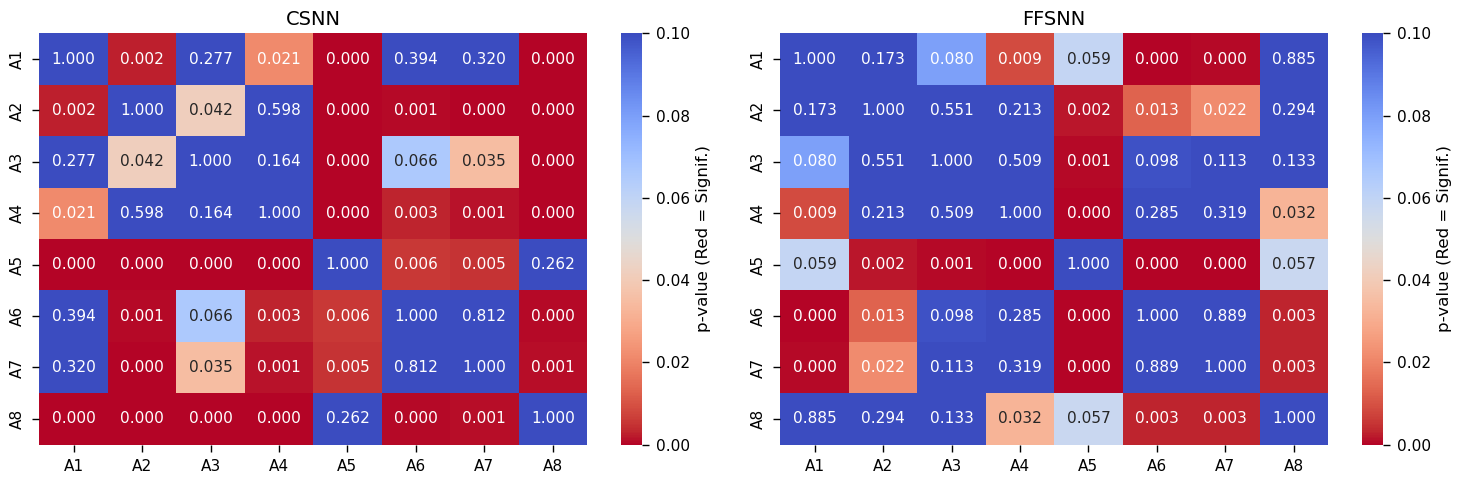

In [6]:
configs = sorted(df_A['Config'].unique())
p_matrix_csnn = np.zeros((len(configs), len(configs)))
p_matrix_ffsnn = np.zeros((len(configs), len(configs)))
df_A_csnn = df_A[df_A['Model'] == 'CSNN']
for i, c1 in enumerate(configs):
    for j, c2 in enumerate(configs):
        v1 = df_A_csnn[df_A_csnn['Config'] == c1]['Recall'].dropna()
        v2 = df_A_csnn[df_A_csnn['Config'] == c2]['Recall'].dropna()
        if len(v1) > 0 and len(v2) > 0:
            _, p_val = stats.mannwhitneyu(v1, v2, alternative='two-sided')
            p_matrix_csnn[i, j] = p_val
        else:
            p_matrix_csnn[i, j] = 1.0
df_A_ffsnn = df_A[df_A['Model'] == 'FFSNN']
for i, c1 in enumerate(configs):
    for j, c2 in enumerate(configs):
        v1 = df_A_ffsnn[df_A_ffsnn['Config'] == c1]['Recall'].dropna()
        v2 = df_A_ffsnn[df_A_ffsnn['Config'] == c2]['Recall'].dropna()
        if len(v1) > 0 and len(v2) > 0:
            _, p_val = stats.mannwhitneyu(v1, v2, alternative='two-sided')
            p_matrix_ffsnn[i, j] = p_val
        else:
            p_matrix_ffsnn[i, j] = 1.0
fig, axes = plt.subplots(1, 2, figsize=(15, 5)) 
sns.heatmap(p_matrix_csnn, xticklabels=configs, yticklabels=configs, annot=True, 
    cmap="coolwarm_r", vmin=0, vmax=0.1, ax=axes[0], fmt=".3f", 
    cbar_kws={'label': 'p-value (Red = Signif.)'}, annot_kws={'size': 11}
)
axes[0].set_title('CSNN')
sns.heatmap(p_matrix_ffsnn, xticklabels=configs, yticklabels=configs, annot=True, 
    cmap="coolwarm_r", vmin=0, vmax=0.1, ax=axes[1], fmt=".3f", 
    cbar_kws={'label': 'p-value (Red = Signif.)'}, annot_kws={'size': 11}
)
axes[1].set_title('FFSNN')
plt.tight_layout()
#plt.savefig(os.path.join(PATH, 'plots/exp_a_stats.pdf'), dpi=300, bbox_inches='tight', pad_inches=0.1)
plt.show()

In [7]:
order_B = ['T=1', 'T=5', 'T=10', 'T=20', 'T=30', 'T=40', 'T=50']
df_B = df_all[df_all['Exp_Group'] == 'Exp B (Timesteps)'].copy()
configs = sorted(df_B['Config'].unique(), key=lambda x: order_B.index(x) if x in order_B else len(order_B))
df_B['Config'] = pd.Categorical(df_B['Config'], categories=configs, ordered=True)
max_values = df_B.groupby(['Model', 'Config'])['Recall'].max().reset_index()
max_values

,Model,Config,Recall
0,CSNN,T=5,0.504202
1,CSNN,T=10,0.504902
2,CSNN,T=20,0.513305
3,CSNN,T=30,0.499300
4,CSNN,T=40,0.497199
5,CSNN,T=50,0.499300
6,FFSNN,T=5,0.495798
7,FFSNN,T=10,0.493697
8,FFSNN,T=20,0.499300
9,FFSNN,T=30,0.494398


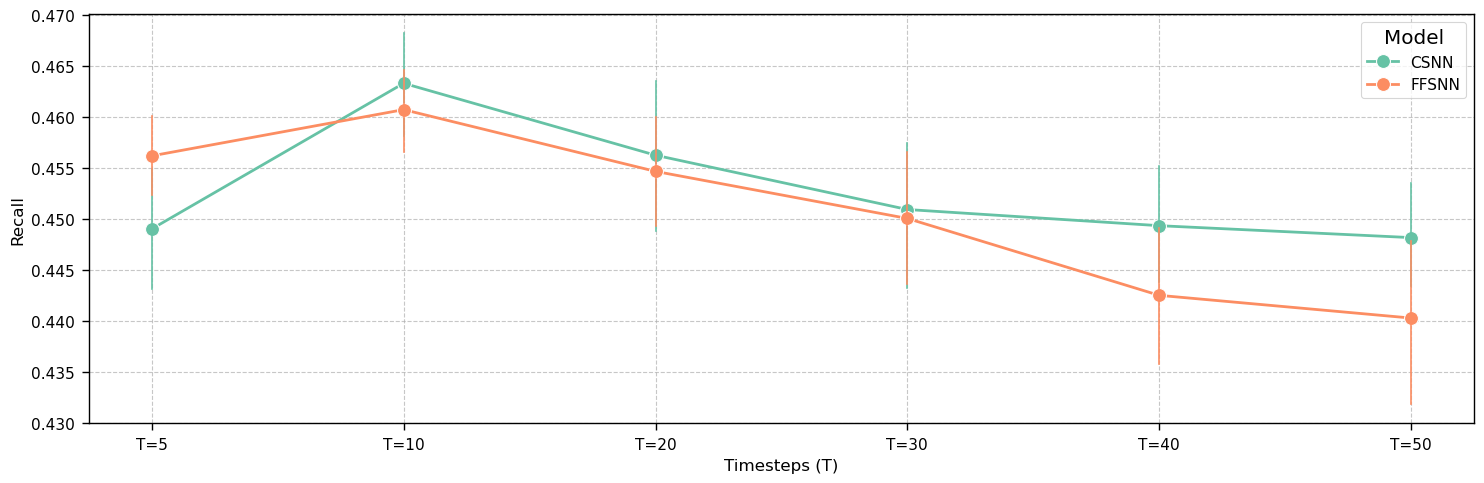

In [8]:
fig, axes = plt.subplots(1, 1, figsize=(15, 5))
sns.lineplot(data=df_B, x='Config', y='Recall', hue='Model', marker='o', markersize=10, linewidth=2, err_style="bars")
plt.xlabel('Timesteps (T)')
plt.ylabel('Recall')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
#plt.savefig(os.path.join(PATH, 'plots/exp_b_lineplot.pdf'), dpi=300, bbox_inches='tight', pad_inches=0.1)
plt.show()

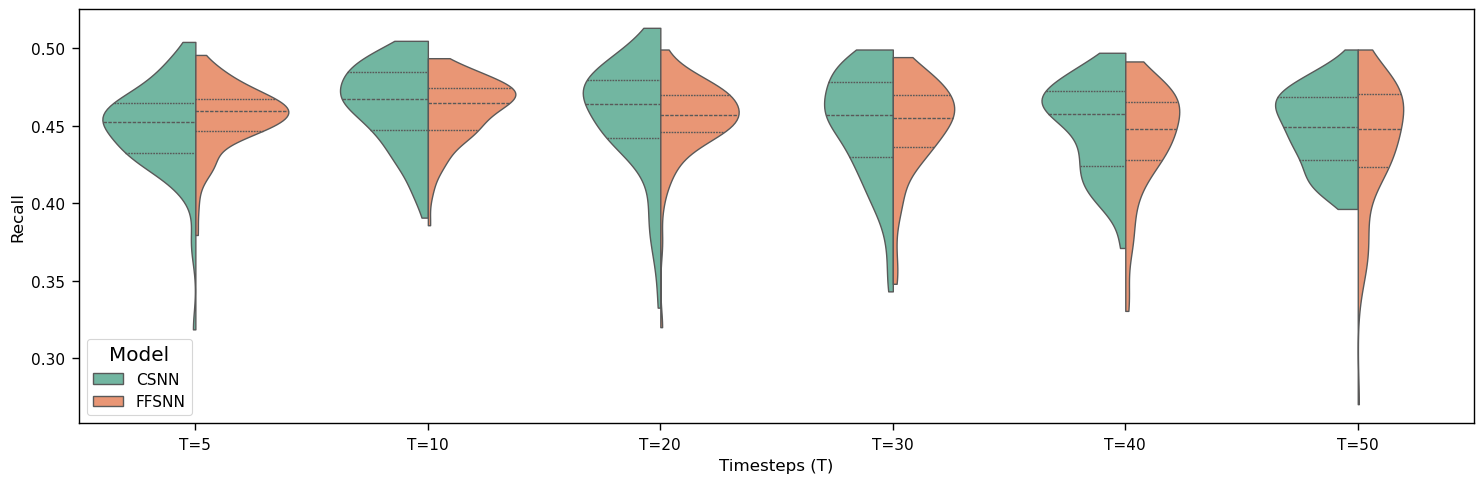

In [9]:
fig, axes = plt.subplots(1, 1, figsize=(15, 5))
sns.violinplot(data=df_B, x='Config', y='Recall', hue='Model', split=True, inner="quart", ax=axes, cut=0)
axes.set_xlabel('Timesteps (T)')
axes.set_ylabel('Recall')
plt.tight_layout()
plt.savefig(os.path.join(PATH, 'plots/exp_b_violin.pdf'), dpi=300, bbox_inches='tight', pad_inches=0.1)
plt.show()

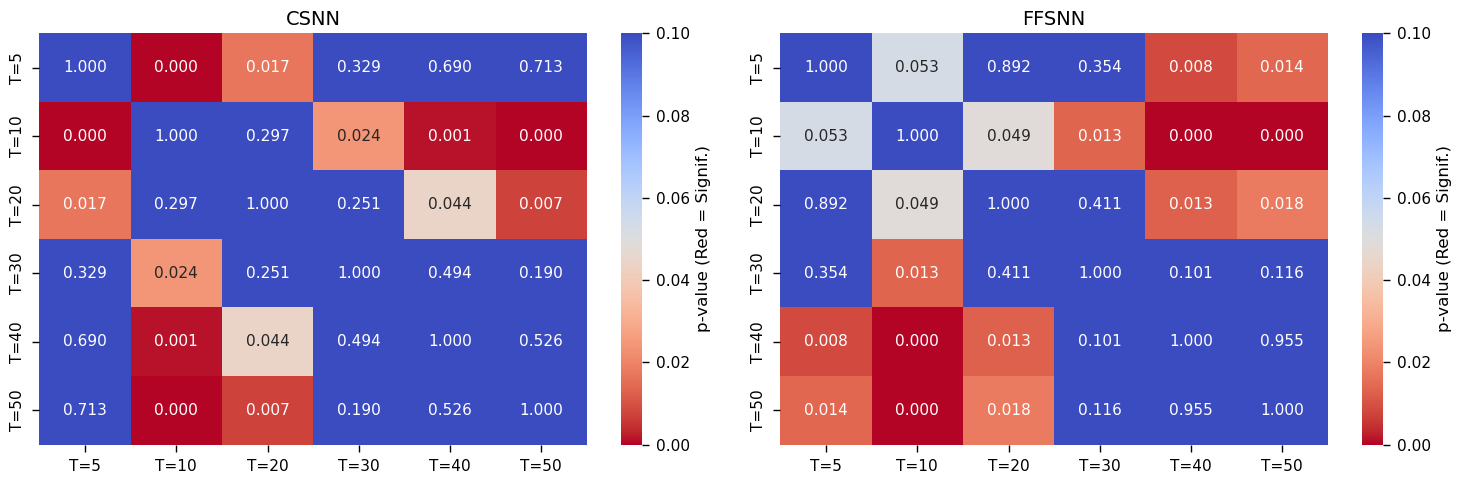

In [10]:
order_B = ['T=1', 'T=5', 'T=10', 'T=20', 'T=30', 'T=40', 'T=50']
configs = sorted(df_B['Config'].unique(), key=lambda x: order_B.index(x) if x in order_B else len(order_B))
p_matrix_csnn = np.zeros((len(configs), len(configs)))
p_matrix_ffsnn = np.zeros((len(configs), len(configs)))
df_B_csnn = df_B[df_B['Model'] == 'CSNN']
for i, c1 in enumerate(configs):
    for j, c2 in enumerate(configs):
        v1 = df_B_csnn[df_B_csnn['Config'] == c1]['Recall'].dropna()
        v2 = df_B_csnn[df_B_csnn['Config'] == c2]['Recall'].dropna()
        if len(v1) > 0 and len(v2) > 0:
            _, p_val = stats.mannwhitneyu(v1, v2, alternative='two-sided')
            p_matrix_csnn[i, j] = p_val
        else:
            p_matrix_csnn[i, j] = 1.0
df_B_ffsnn = df_B[df_B['Model'] == 'FFSNN']
for i, c1 in enumerate(configs):
    for j, c2 in enumerate(configs):
        v1 = df_B_ffsnn[df_B_ffsnn['Config'] == c1]['Recall'].dropna()
        v2 = df_B_ffsnn[df_B_ffsnn['Config'] == c2]['Recall'].dropna()
        if len(v1) > 0 and len(v2) > 0:
            _, p_val = stats.mannwhitneyu(v1, v2, alternative='two-sided')
            p_matrix_ffsnn[i, j] = p_val
        else:
            p_matrix_ffsnn[i, j] = 1.0
fig, axes = plt.subplots(1, 2, figsize=(15, 5)) 

sns.heatmap(p_matrix_csnn, xticklabels=configs, yticklabels=configs, annot=True, 
    cmap="coolwarm_r", vmin=0, vmax=0.1, ax=axes[0], fmt=".3f", 
    cbar_kws={'label': 'p-value (Red = Signif.)'}, annot_kws={'size': 11}
)
axes[0].set_title('CSNN')

sns.heatmap(p_matrix_ffsnn, xticklabels=configs, yticklabels=configs, annot=True, 
    cmap="coolwarm_r", vmin=0, vmax=0.1, ax=axes[1], fmt=".3f", 
    cbar_kws={'label': 'p-value (Red = Signif.)'}, annot_kws={'size': 11}
)
axes[1].set_title('FFSNN')
plt.tight_layout()
#plt.savefig(os.path.join(PATH, 'plots/exp_b_stats.pdf'), dpi=300, bbox_inches='tight', pad_inches=0.1)
plt.show()

In [11]:
order_C = ['$\sigma$=1', '$\sigma$=5', '$\sigma$=10', '$\sigma$=20', '$\sigma$=30', '$\sigma$=40', '$\sigma$=50']
df_C = df_all[df_all['Exp_Group'] == 'Exp C (Slopes)'].copy()
configs = sorted(df_C['Config'].unique(), key=lambda x: order_C.index(x) if x in order_C else len(order_C))
df_C['Config'] = pd.Categorical(df_C['Config'], categories=configs, ordered=True)
max_values = df_C.groupby(['Model', 'Config'])['Recall'].max().reset_index()
max_values

,Model,Config,Recall
0,CSNN,$\sigma$=5,0.515406
1,CSNN,$\sigma$=10,0.516106
2,CSNN,$\sigma$=20,0.512605
3,CSNN,$\sigma$=30,0.508403
4,CSNN,$\sigma$=40,0.509104
5,CSNN,$\sigma$=50,0.490896
6,FFSNN,$\sigma$=5,0.494398
7,FFSNN,$\sigma$=10,0.500000
8,FFSNN,$\sigma$=20,0.488095
9,FFSNN,$\sigma$=30,0.500000


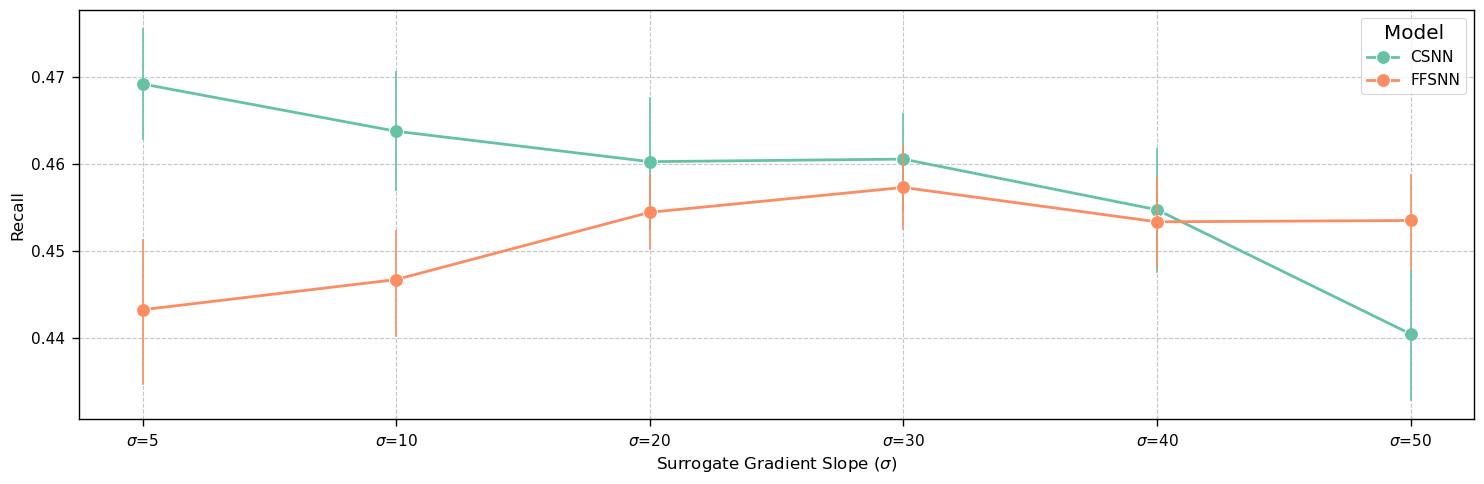

In [12]:
fig, axes = plt.subplots(1, 1, figsize=(15, 5))
sns.lineplot(data=df_C, x='Config', y='Recall', hue='Model', marker='o', markersize=10, linewidth=2, err_style="bars")
plt.xlabel('Surrogate Gradient Slope ($\sigma$)')
plt.ylabel('Recall')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
#plt.savefig(os.path.join(PATH, 'plots/exp_c_lineplot.pdf'), dpi=300, bbox_inches='tight', pad_inches=0.1)
plt.show()

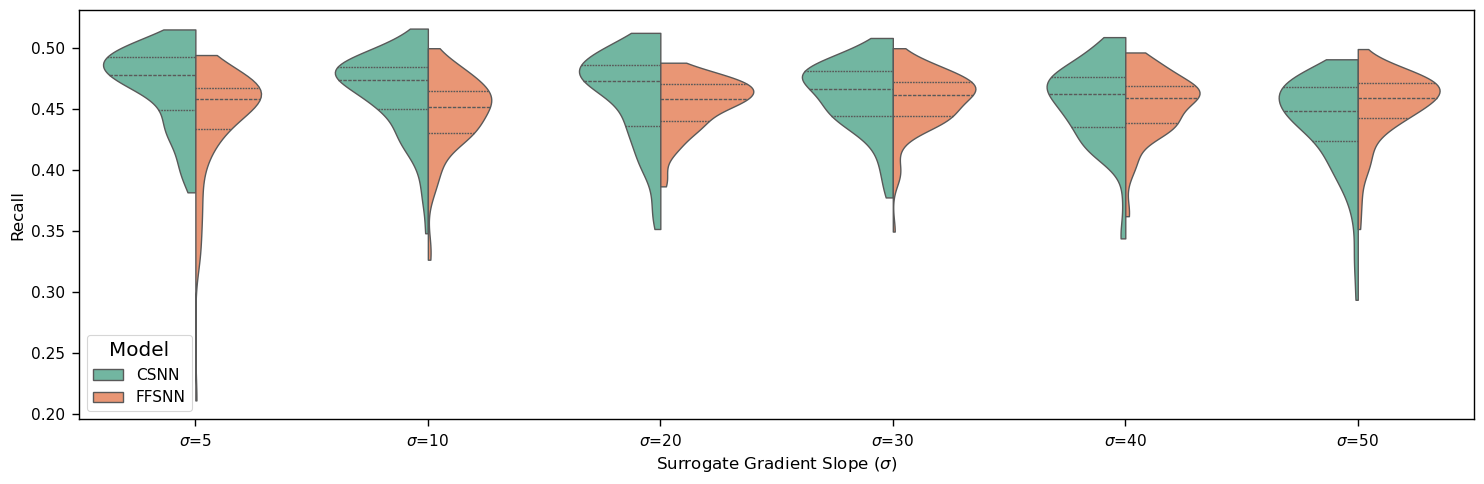

In [13]:
df_C = df_C.sort_values(by=['Model', 'Config'])
fig, axes = plt.subplots(1, 1, figsize=(15, 5))
sns.violinplot(data=df_C, x='Config', y='Recall', hue='Model', split=True, inner="quart", ax=axes, cut=0)
axes.set_xlabel('Surrogate Gradient Slope ($\sigma$)')
axes.set_ylabel('Recall')
plt.tight_layout()
#plt.savefig(os.path.join(PATH, 'plots/exp_c_violin.pdf'), dpi=300, bbox_inches='tight', pad_inches=0.1)
plt.show()

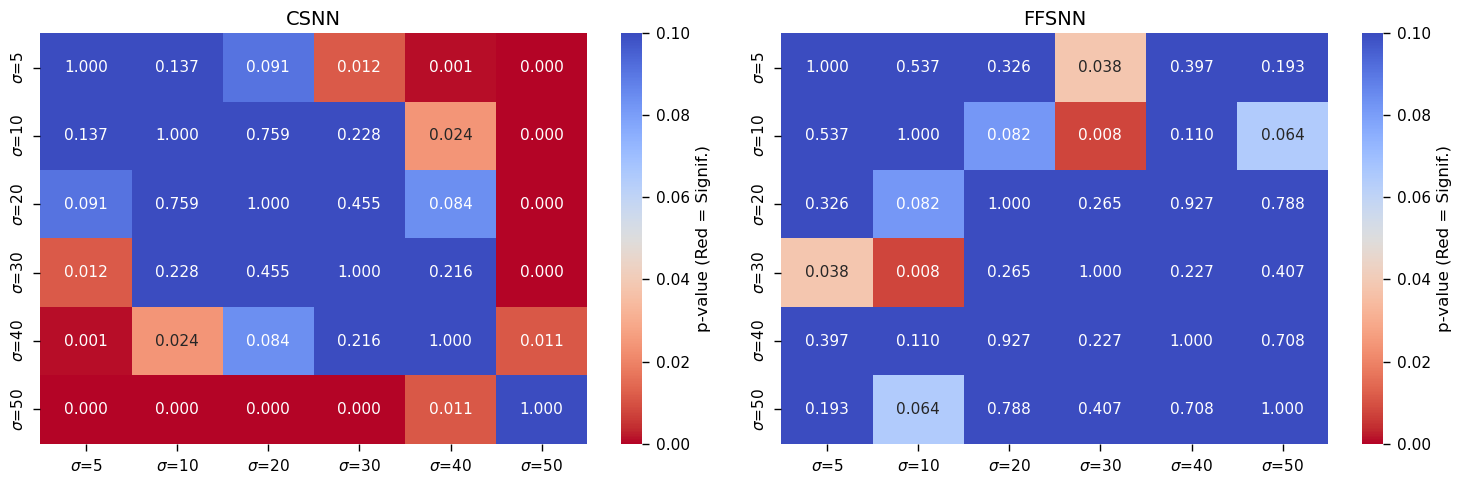

In [14]:
order_C = ['$\sigma$=5', '$\sigma$=10', '$\sigma$=20', '$\sigma$=30', '$\sigma$=40', '$\sigma$=50']
configs = sorted(df_C['Config'].unique(), key=lambda x: order_C.index(x) if x in order_C else len(order_C))
p_matrix_csnn = np.zeros((len(configs), len(configs)))
p_matrix_ffsnn = np.zeros((len(configs), len(configs)))
df_C_csnn = df_C[df_C['Model'] == 'CSNN']
for i, c1 in enumerate(configs):
    for j, c2 in enumerate(configs):
        v1 = df_C_csnn[df_C_csnn['Config'] == c1]['Recall'].dropna()
        v2 = df_C_csnn[df_C_csnn['Config'] == c2]['Recall'].dropna()
        if len(v1) > 0 and len(v2) > 0:
            _, p_val = stats.mannwhitneyu(v1, v2, alternative='two-sided')
            p_matrix_csnn[i, j] = p_val
        else:
            p_matrix_csnn[i, j] = 1.0
df_C_ffsnn = df_C[df_C['Model'] == 'FFSNN']
for i, c1 in enumerate(configs):
    for j, c2 in enumerate(configs):
        v1 = df_C_ffsnn[df_C_ffsnn['Config'] == c1]['Recall'].dropna()
        v2 = df_C_ffsnn[df_C_ffsnn['Config'] == c2]['Recall'].dropna()
        if len(v1) > 0 and len(v2) > 0:
            _, p_val = stats.mannwhitneyu(v1, v2, alternative='two-sided')
            p_matrix_ffsnn[i, j] = p_val
        else:
            p_matrix_ffsnn[i, j] = 1.0
fig, axes = plt.subplots(1, 2, figsize=(15, 5)) 
sns.heatmap(p_matrix_csnn, xticklabels=configs, yticklabels=configs, annot=True, 
    cmap="coolwarm_r", vmin=0, vmax=0.1, ax=axes[0], fmt=".3f", 
    cbar_kws={'label': 'p-value (Red = Signif.)'}, annot_kws={'size': 11}
)
axes[0].set_title('CSNN')

sns.heatmap(p_matrix_ffsnn, xticklabels=configs, yticklabels=configs, annot=True, 
    cmap="coolwarm_r", vmin=0, vmax=0.1, ax=axes[1], fmt=".3f", 
    cbar_kws={'label': 'p-value (Red = Signif.)'}, annot_kws={'size': 11}
)
axes[1].set_title('FFSNN')
plt.tight_layout()
#plt.savefig(os.path.join(PATH, 'plots/exp_c_stats.pdf'), dpi=300, bbox_inches='tight', pad_inches=0.1)
plt.show()

In [15]:
df_D1 = df_all[df_all['Exp_Group'] == 'Exp D1 (ML Models)'].copy().sort_values(by=['Model', 'Config'])
max_values = df_D1.groupby(['Model', 'Dataset'])[['Recall', 'ROC-AUC', 'PR-AUC', 'PE$_{\\text{Age}}$']].max().reset_index()
max_values

,Model,Dataset,Recall,ROC-AUC,PR-AUC,PE$_{\text{Age}}$
0,ADA,BAF-Base,0.574230,0.897543,0.507373,0.355400
1,ADA,BAF-TypeI,0.536415,0.890441,0.507373,0.707242
2,ADA,BAF-TypeII,0.561625,0.899950,0.507373,0.135409
3,ADA,BAF-TypeIII,0.686992,0.936446,0.363027,0.946650
4,ADA,BAF-TypeIV,0.452236,0.861627,0.504660,0.195611
5,ADA,BAF-TypeV,0.426829,0.855728,0.076885,0.938053
6,CAT,BAF-Base,0.586134,0.901138,0.227804,0.392493
7,CAT,BAF-TypeI,0.556723,0.895689,0.226228,0.999944
8,CAT,BAF-TypeII,0.577031,0.903011,0.224025,0.174538
9,CAT,BAF-TypeIII,0.778455,0.956716,0.528719,0.773049


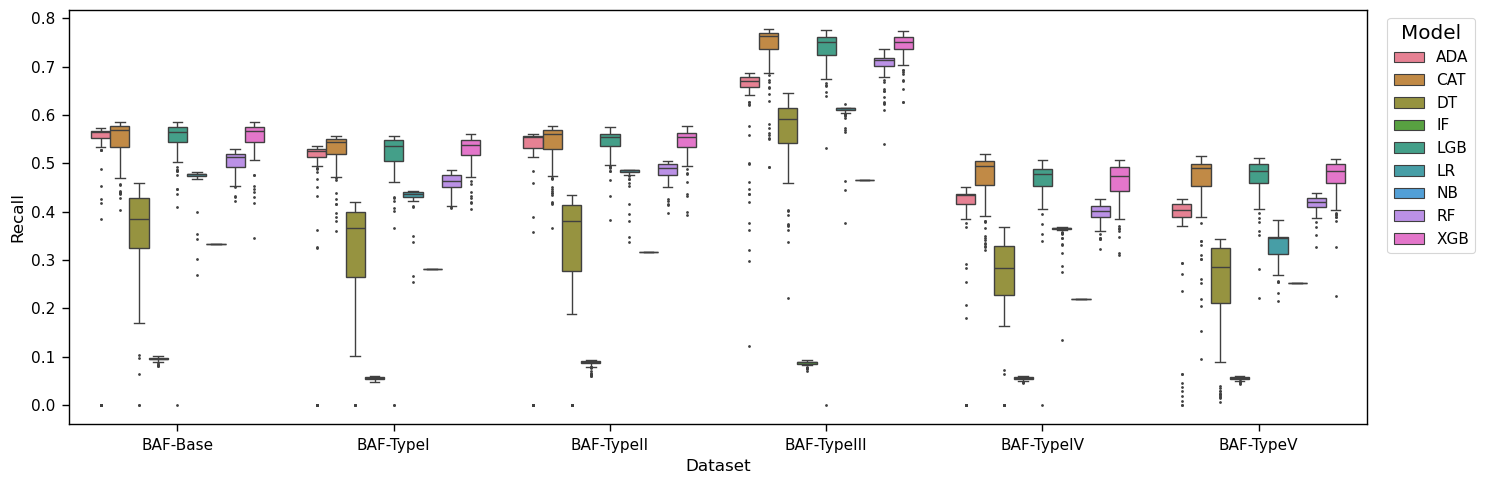

In [16]:
fig, axes = plt.subplots(1, 1, figsize=(15, 5))
sns.boxplot(data=df_D1, x='Dataset', y='Recall', hue='Model', ax=axes, fliersize=1)
plt.xlabel('Dataset')
plt.ylabel('Recall')
plt.legend(title='Model', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
#plt.savefig(os.path.join(PATH, 'plots/exp_d1_boxplot_recall.pdf'), dpi=300, bbox_inches='tight', pad_inches=0.1)
plt.show()

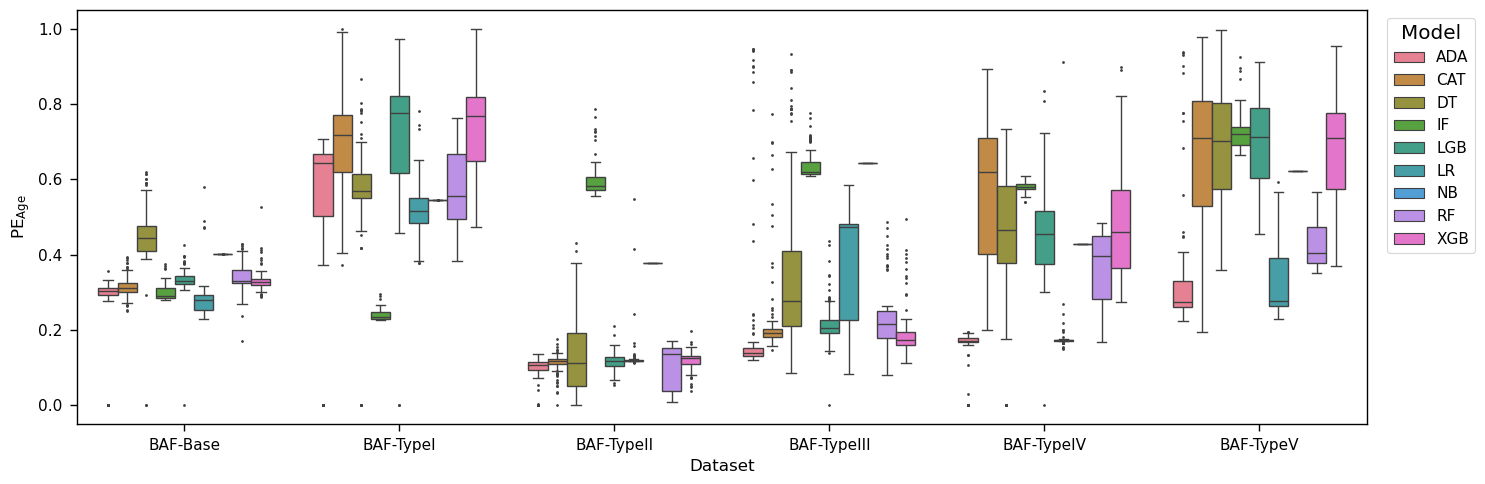

In [17]:
fig, axes = plt.subplots(1, 1, figsize=(15, 5))
sns.boxplot(data=df_D1, x='Dataset', y='PE$_{\\text{Age}}$', hue='Model', ax=axes, fliersize=1)
plt.xlabel('Dataset')
plt.ylabel('PE$_{\\text{Age}}$')
plt.legend(title='Model', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
#plt.savefig(os.path.join(PATH, 'plots/exp_d1_boxplot_fairness.pdf'), dpi=300, bbox_inches='tight', pad_inches=0.1)
plt.show()

In [18]:
df_D2_max = df_all[df_all['Exp_Group'] == 'Exp D2 (SNN - Max)'].copy().sort_values(by=['Model', 'Dataset', 'Config'])
max_values = df_D2_max.groupby(['Model', 'Dataset', 'Config'])[['Recall', 'ROC-AUC', 'PR-AUC', 'PE$_{\\text{Age}}$']].max().reset_index()
max_values

,Model,Dataset,Config,Recall,ROC-AUC,PR-AUC,PE$_{\text{Age}}$
0,CSNN,BAF-Base,Max,0.524510,0.872787,0.190963,0.440527
1,CSNN,BAF-TypeI,Max,0.481092,0.862410,0.184656,0.997184
2,CSNN,BAF-TypeII,Max,0.506303,0.876204,0.193297,0.392907
3,CSNN,BAF-TypeIII,Max,0.694106,0.934597,0.422975,0.527748
4,CSNN,BAF-TypeIV,Max,0.436992,0.840320,0.095047,0.544982
5,CSNN,BAF-TypeV,Max,0.436992,0.842120,0.103126,0.594878
6,FFSNN,BAF-Base,Max,0.509104,0.869461,0.195756,0.440855
7,FFSNN,BAF-TypeI,Max,0.460084,0.859234,0.192514,0.984181
8,FFSNN,BAF-TypeII,Max,0.500000,0.874600,0.218868,0.198419
9,FFSNN,BAF-TypeIII,Max,0.720528,0.941726,0.499157,0.396394


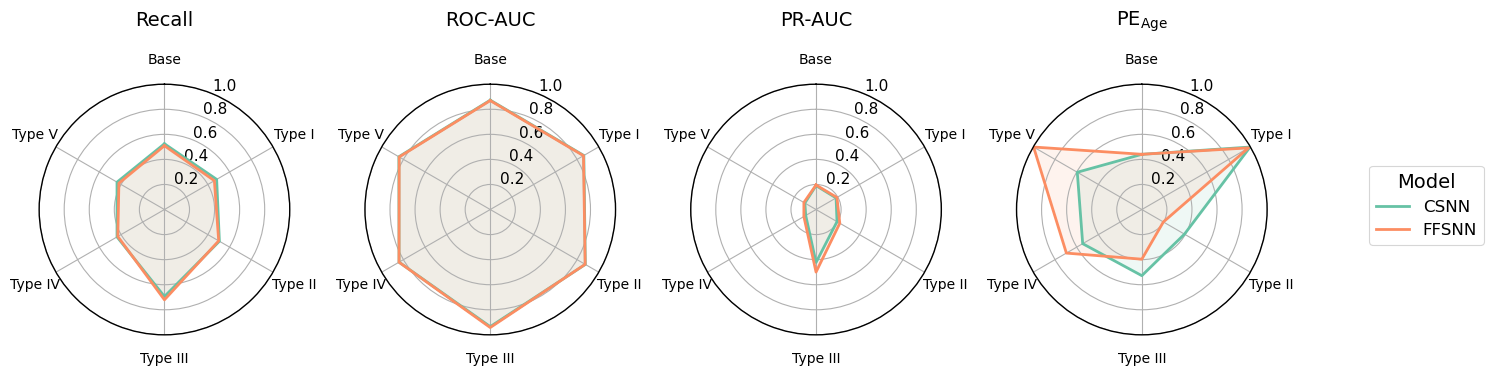

In [19]:
metrics = ['Recall', 'ROC-AUC', 'PR-AUC', 'PE$_{\\text{Age}}$']
max_values = df_D2_max.groupby(['Model', 'Dataset'])[metrics].max().reset_index()
max_values['Dataset'].replace({'BAF-Base': 'Base', 'BAF-TypeI': 'Type I', 'BAF-TypeII': 'Type II', 'BAF-TypeIII': 'Type III', 'BAF-TypeIV': 'Type IV', 'BAF-TypeV': 'Type V'}, inplace=True)
fig, axes = plt.subplots(1, 4, figsize=(15, 5), subplot_kw={'polar': True})
axes = axes.flatten()
for idx, metric in enumerate(metrics):
    ax = axes[idx]
    df_pivot = max_values.pivot(index='Model', columns='Dataset', values=metric)
    categories = df_pivot.columns.tolist()
    N = len(categories)
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1]
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, size=10)
    ax.set_ylim(0, 1)
    for model_config in df_pivot.index:
        values = df_pivot.loc[model_config].tolist()
        values += values[:1] 
        ax.plot(angles, values, linewidth=2, linestyle='solid', label=model_config)
        ax.fill(angles, values, alpha=0.1)
    ax.set_title(f'{metric}', size=14, y=1.2)
handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc='center right', bbox_to_anchor=(1, 0.5), title="Model", fontsize=12, title_fontsize=14)
plt.tight_layout()
plt.subplots_adjust(right=0.85, hspace=0.4, wspace=0.3)
#plt.savefig(os.path.join(PATH, 'plots/exp_d2_radarplot.pdf'), dpi=300, bbox_inches='tight', pad_inches=0.1)
plt.show()